# 03 — Categorical Exploratory Data Analysis & Summary Tables

**Project:** Predicting Late Delivery Risk in Supply Chain Operations (CAP 3764, Team 4)
**Dataset:** DataCo Smart Supply Chain for Big Data Analysis (Kaggle)
**Author of this notebook:** Abhiram

## 1. Objective

This notebook examines how **categorical variables** relate to the late-delivery outcome
(`late_delivery_risk`). It produces the grouped summary tables and categorical visualizations
required for the Phase 1 EDA.

Ground rules for everything below:

- **Descriptive only.** No models are trained, nothing is encoded, no train/test split is made.
- **Association ≠ causation.** A category with a higher late rate is *associated* with lateness in this
  dataset; it does not *cause* it.
- **Follows `docs/FEATURE_POLICY.md`.** Leakage / post-outcome variables (e.g. `delivery_status`) are
  analysed only to confirm why they are forbidden — never presented as useful predictors.
- **Grain = order item.** Each row is an order-item record, not an independent order. Counts are labelled
  `record_count` (order-item records) unless explicitly computed at the unique-order level.

**Team context.** This notebook continues from Raj's preprocessing foundation (PR #3) and runs alongside Tutu's numerical EDA (02_numerical_eda). Both use the same cleaned dataset.

The shared reference numbers are 180,519 order-item records, 47 columns, 65,752 unique orders, and an overall late-delivery rate of 54.83% (98,977 late records). Like `02_numerical_eda`, results here are **order-item-weighted** unless a table is explicitly at unique-order level. Figures are saved to `reports/figures/categorical/`, next to the numerical figures in `reports/figures/numerical/`.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio

# Locate the repository root (works whether the kernel starts in notebooks/ or the repo root)
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "environment.yml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.preprocessing import DEFAULT_PROCESSED_DATA_PATH, run_preprocessing
from src.leakage_guardrails import (
    TARGET_COLUMNS, EDA_ONLY_COLUMNS, IDENTIFIER_COLUMNS,
    PREDICTION_SAFE_CANDIDATES, REVIEW_REQUIRED_COLUMNS,
)

FIG_DIR = REPO_ROOT / "reports" / "figures" / "categorical"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "late_delivery_risk"
MIN_RECORDS = 500   # minimum order-item records for a category to be ranked/plotted on its own

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "axes.titleweight": "bold"})
# Load plotly.js from the CDN so the notebook file stays small.
pio.renderers.default = "plotly_mimetype+notebook_connected"
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.3f}".format)

## 2. Load the Cleaned Data

The cleaned dataset is produced by the team's existing deterministic pipeline (`src/preprocessing.py`,
merged in PR #3). If `data/processed/dataco_clean.csv` does not exist yet, the cell below regenerates it
from `data/raw/DataCoSupplyChainDataset.csv` using that same pipeline — no new cleaning logic is introduced.

In [2]:
if not DEFAULT_PROCESSED_DATA_PATH.exists():
    print("Processed file not found -> running the team preprocessing pipeline...")
    run_preprocessing()

df = pd.read_csv(
    DEFAULT_PROCESSED_DATA_PATH,
    parse_dates=["order_date_dateorders", "shipping_date_dateorders"],
)

n_rows, n_cols = df.shape
n_orders = df["order_id"].nunique()
print(f"Order-item records (rows): {n_rows:,}")
print(f"Columns:                   {n_cols}")
print(f"Unique order_id values:    {n_orders:,}")
print(f"Avg items per order:       {n_rows / n_orders:.2f}")

Order-item records (rows): 180,519
Columns:                   47
Unique order_id values:    65,752
Avg items per order:       2.75


**Grain reminder:** rows are **order-item records**. One order can contain several items, so the row
count is larger than the number of unique orders. Every "count" in this notebook is a count of order-item
records unless a column is explicitly named `unique_orders`.

## 3. Identify Categorical Variables

Categorical columns are found programmatically (string/object dtype), then classified using the
**same constants the team's leakage guardrail enforces** (`src/leakage_guardrails.py`), so this notebook
cannot drift away from the feature policy.

In [3]:
cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()

def policy_label(col):
    if col in TARGET_COLUMNS:            return "TARGET"
    if col in EDA_ONLY_COLUMNS:          return "EDA ONLY (leakage / post-outcome)"
    if col in IDENTIFIER_COLUMNS:        return "IDENTIFIER (structure only)"
    if col in PREDICTION_SAFE_CANDIDATES:return "PREDICTION-SAFE CANDIDATE"
    if col in REVIEW_REQUIRED_COLUMNS:   return "REVIEW REQUIRED"
    return "UNCLASSIFIED"

def cardinality_band(n):
    if n <= 10:   return "low (<=10)"
    if n <= 60:   return "medium (11-60)"
    return "high (>60)"

cat_overview = (
    pd.DataFrame({
        "column": cat_cols,
        "unique_values": [df[c].nunique(dropna=True) for c in cat_cols],
        "missing_values": [int(df[c].isna().sum()) for c in cat_cols],
    })
    .assign(cardinality=lambda t: t["unique_values"].map(cardinality_band),
            feature_policy=lambda t: t["column"].map(policy_label))
    .sort_values("unique_values")
    .reset_index(drop=True)
)
cat_overview

,column,unique_values,missing_values,cardinality,feature_policy
0,customer_country,2,0,low (<=10),REVIEW REQUIRED
1,customer_segment,3,0,low (<=10),REVIEW REQUIRED
2,type,4,0,low (<=10),REVIEW REQUIRED
3,shipping_mode,4,0,low (<=10),PREDICTION-SAFE CANDIDATE
4,delivery_status,4,0,low (<=10),EDA ONLY (leakage / post-outcome)
5,market,5,0,low (<=10),REVIEW REQUIRED
6,order_status,9,0,low (<=10),REVIEW REQUIRED
7,department_name,11,0,medium (11-60),REVIEW REQUIRED
8,order_region,23,0,medium (11-60),REVIEW REQUIRED
9,customer_state,46,0,medium (11-60),REVIEW REQUIRED


**How these columns are used in this notebook:**

| Group | Columns | Treatment |
|---|---|---|
| Useful business categories (low/medium cardinality) | `shipping_mode`, `market`, `order_region`, `customer_segment`, `category_name`, `department_name`, `type` | Full summary tables + charts |
| Leakage / post-outcome | `delivery_status` | Descriptive only, to confirm the leakage classification |
| Timing-dependent | `order_status` | Descriptive only, kept as **REVIEW REQUIRED** |
| High cardinality | `order_country`, `order_city`, `order_state`, `customer_city`, `customer_state`, `product_name` | Top-N / minimum-count filtering only; no full charts |
| Not analytically useful | `product_image` (URL), `customer_country` (2 values, store location) | Excluded from charts |

Direct PII (names, emails, passwords, street addresses) was already removed by preprocessing; the check
below confirms none slipped through.

In [4]:
pii_cols = {"customer_email", "customer_password", "customer_fname", "customer_lname", "customer_street"}
leaked = sorted(pii_cols & set(df.columns))
assert not leaked, f"STOP: direct PII present in cleaned data -> {leaked}. Flag for Raj."
print("PII check passed: no direct PII columns in the cleaned dataset.")

PII check passed: no direct PII columns in the cleaned dataset.


## Helper: grouped late-delivery summary

One reusable function builds every summary table so all tables are computed identically:

- `record_count` — order-item records in the category (**volume**)
- `share_of_records` — the category's share of all records
- `late_count` — records with `late_delivery_risk = 1`
- `late_rate` — `late_count / record_count` (**rate**)
- `ci_low` / `ci_high` — 95% Wilson confidence interval for the rate. Wide intervals = small,
  less reliable categories. This is how we keep **volume** and **rate** from being confused.

In [5]:
def wilson_ci(k, n, z=1.96):
    k, n = np.asarray(k, float), np.asarray(n, float)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return np.clip(center - half, 0, 1), np.clip(center + half, 0, 1)

def late_summary(data, col, min_records=None, sort_by="late_rate"):
    t = (data.groupby(col, dropna=False)[TARGET]
             .agg(record_count="size", late_count="sum")
             .reset_index())
    t["share_of_records"] = t["record_count"] / t["record_count"].sum()
    t["late_rate"] = t["late_count"] / t["record_count"]
    t["ci_low"], t["ci_high"] = wilson_ci(t["late_count"], t["record_count"])
    if min_records is not None:
        t["meets_min_records"] = t["record_count"] >= min_records
    t = t.sort_values(sort_by, ascending=False).reset_index(drop=True)
    return t[[col, "record_count", "share_of_records", "late_count", "late_rate", "ci_low", "ci_high"]
             + (["meets_min_records"] if min_records is not None else [])]

def style_summary(t):
    fmt = {"record_count": "{:,.0f}", "late_count": "{:,.0f}", "share_of_records": "{:.1%}",
           "late_rate": "{:.1%}", "ci_low": "{:.1%}", "ci_high": "{:.1%}"}
    return (t.style.format(fmt)
             .background_gradient(subset=["late_rate"], cmap="Reds", vmin=0, vmax=1)
             .bar(subset=["record_count"], color="#9ecae1")
             .hide(axis="index"))

def plot_rate(t, col, title, fname, overall_rate, top_n=None):
    t = t.head(top_n) if top_n else t
    t = t.sort_values("late_rate")
    fig, ax = plt.subplots(figsize=(9, max(3, 0.42 * len(t) + 1.2)))
    err = np.vstack([t["late_rate"] - t["ci_low"], t["ci_high"] - t["late_rate"]])
    ax.barh(t[col].astype(str), t["late_rate"], xerr=err, color="#d6604d",
            ecolor="#555555", capsize=3)
    ax.axvline(overall_rate, ls="--", color="black", lw=1, label=f"Overall rate ({overall_rate:.1%})")
    for i, (r, hi, n) in enumerate(zip(t["late_rate"], t["ci_high"], t["record_count"])):
        ax.text(hi + 0.02, i, f"{r:.1%}  (n={n:,})", va="center", fontsize=8.5,
                bbox=dict(facecolor="white", edgecolor="none", pad=1, alpha=0.85))
    ax.set_xlim(0, 1.25)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}" if x <= 1 else ""))
    ax.set_xlabel("Late-delivery rate (share of order-item records with late_delivery_risk = 1)")
    ax.set_ylabel(col.replace("_", " ").title())
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, bbox_inches="tight")
    plt.show()

## 4. Target Variable — `late_delivery_risk`

`late_delivery_risk = 1` means the shipment was late; `0` means it was not. This is the **target**, so it
is never a feature.

label,record_count,percentage
Not late (0),"81,542",45.2%
Late (1),"98,977",54.8%


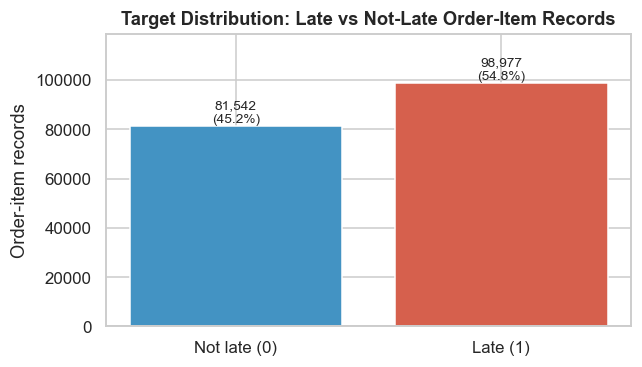

Overall late-delivery rate: 54.83% (98,977 late of 180,519 order-item records)


In [6]:
target_tbl = (df[TARGET].value_counts().rename_axis(TARGET).reset_index(name="record_count")
                .assign(percentage=lambda t: t["record_count"] / t["record_count"].sum())
                .sort_values(TARGET).reset_index(drop=True))
target_tbl["label"] = target_tbl[TARGET].map({0: "Not late (0)", 1: "Late (1)"})
OVERALL_LATE = df[TARGET].mean()
display(target_tbl[["label", "record_count", "percentage"]]
        .style.format({"record_count": "{:,.0f}", "percentage": "{:.1%}"}).hide(axis="index"))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(target_tbl["label"], target_tbl["record_count"], color=["#4393c3", "#d6604d"])
for i, (n, p) in enumerate(zip(target_tbl["record_count"], target_tbl["percentage"])):
    ax.text(i, n, f"{n:,}\n({p:.1%})", ha="center", va="bottom", fontsize=9)
ax.set_title("Target Distribution: Late vs Not-Late Order-Item Records")
ax.set_ylabel("Order-item records")
ax.set_ylim(0, target_tbl["record_count"].max() * 1.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "target_distribution.png", bbox_inches="tight"); plt.show()
print(f"Overall late-delivery rate: {OVERALL_LATE:.2%} ({int(df[TARGET].sum()):,} late of {len(df):,} order-item records)")

**Interpretation.** 98,977 of 180,519 order-item records (54.83%) are flagged late, so the target is only mildly
imbalanced — not a rare-event problem. This overall rate is the **baseline** (dashed line) on every chart
below: a category is only interesting if it sits clearly above or below it. The counts and the rate are
identical to those reported in `02_numerical_eda`, since both notebooks read the same cleaned file.

## 5. Shipping Mode — `shipping_mode`

`shipping_mode` is one of only two **PREDICTION-SAFE CANDIDATES** in the feature policy (it is chosen when
the order is placed), so it is the most important categorical variable in this notebook.

In [7]:
ship_tbl = late_summary(df, "shipping_mode")
style_summary(ship_tbl)

shipping_mode,record_count,share_of_records,late_count,late_rate,ci_low,ci_high
First Class,"27,814",15.4%,"26,513",95.3%,95.1%,95.6%
Second Class,"35,216",19.5%,"26,987",76.6%,76.2%,77.1%
Same Day,"9,737",5.4%,"4,454",45.7%,44.8%,46.7%
Standard Class,"107,752",59.7%,"41,023",38.1%,37.8%,38.4%


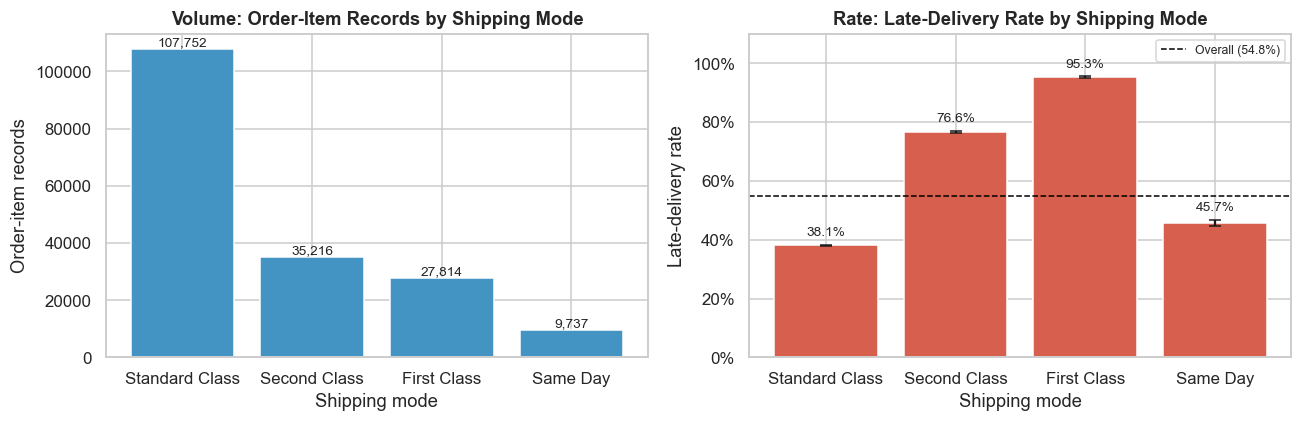

Highest late rate: First Class at 95.3% (n=27,814)
Lowest late rate:  Standard Class at 38.1% (n=107,752)
Spread: 57.3 percentage points


In [8]:
# Volume vs rate side by side — the key "don't confuse count with percentage" chart
t = ship_tbl.sort_values("record_count", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(t["shipping_mode"], t["record_count"], color="#4393c3")
axes[0].set_title("Volume: Order-Item Records by Shipping Mode")
axes[0].set_ylabel("Order-item records"); axes[0].set_xlabel("Shipping mode")
for i, n in enumerate(t["record_count"]): axes[0].text(i, n, f"{n:,}", ha="center", va="bottom", fontsize=9)
axes[1].bar(t["shipping_mode"], t["late_rate"], color="#d6604d",
            yerr=np.vstack([t["late_rate"] - t["ci_low"], t["ci_high"] - t["late_rate"]]), capsize=4)
axes[1].axhline(OVERALL_LATE, ls="--", color="black", lw=1, label=f"Overall ({OVERALL_LATE:.1%})")
axes[1].set_title("Rate: Late-Delivery Rate by Shipping Mode")
axes[1].set_ylabel("Late-delivery rate"); axes[1].set_xlabel("Shipping mode"); axes[1].set_ylim(0, 1.1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
for i, (r, hi) in enumerate(zip(t["late_rate"], t["ci_high"])): axes[1].text(i, hi + 0.03, f"{r:.1%}", ha="center", fontsize=9)
axes[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "late_rate_by_shipping_mode.png", bbox_inches="tight"); plt.show()

hi, lo = ship_tbl.iloc[0], ship_tbl.iloc[-1]
print(f"Highest late rate: {hi.shipping_mode} at {hi.late_rate:.1%} (n={hi.record_count:,})")
print(f"Lowest late rate:  {lo.shipping_mode} at {lo.late_rate:.1%} (n={lo.record_count:,})")
print(f"Spread: {100*(hi.late_rate - lo.late_rate):.1f} percentage points")

In [9]:
# Scheduled shipping days per mode (both fields are prediction-safe candidates; policy notes they overlap)
pd.crosstab(df["shipping_mode"], df["days_for_shipment_scheduled"], margins=True, margins_name="Total")

days_for_shipment_scheduled,0,1,2,4,Total
shipping_mode,,,,,
First Class,0,27814,0,0,27814
Same Day,9737,0,0,0,9737
Second Class,0,0,35216,0,35216
Standard Class,0,0,0,107752,107752
Total,9737,27814,35216,107752,180519


**Interpretation.**

- Shipping mode shows the **largest differences of any categorical variable** in this notebook — tens of
  percentage points between modes, not a few points: First Class 95.3%, Second Class 76.6%, Same Day 45.7%,
  Standard Class 38.1%.
- **First Class and Second Class have the highest late rates**, while Standard Class has the lowest despite
  carrying the most volume (59.7% of records). Volume and rate do not move together here.
- The crosstab shows each mode maps to exactly one `days_for_shipment_scheduled` value: Same Day = 0,
  First Class = 1, Second Class = 2, Standard Class = 4. The late rate is not simply ordered by scheduled
  days: Same Day has the shortest window but sits below the baseline. These are associations in the
  historical data; this notebook does not establish why the modes differ.
- All four modes have thousands of records, so the confidence intervals are narrow and do not overlap.
  Same Day is the smallest group (9,737 records, 5.4%).
- Because the mapping is one-to-one, `shipping_mode` and `days_for_shipment_scheduled` carry the same
  information — consistent with the feature policy's redundancy note for later modeling.

## 6. Geographic Analysis — `market`, `order_region`, `order_country`

These describe where the order is **delivered**. Customer street addresses are removed in preprocessing and
are not used. `customer_city/state/country` describe the store/customer location and are not charted.

In [10]:
market_tbl = late_summary(df, "market")
style_summary(market_tbl)

market,record_count,share_of_records,late_count,late_rate,ci_low,ci_high
Europe,"50,252",27.8%,"27,743",55.2%,54.8%,55.6%
Pacific Asia,"41,260",22.9%,"22,712",55.0%,54.6%,55.5%
USCA,"25,799",14.3%,"14,138",54.8%,54.2%,55.4%
Africa,"11,614",6.4%,"6,340",54.6%,53.7%,55.5%
LATAM,"51,594",28.6%,"28,044",54.4%,53.9%,54.8%


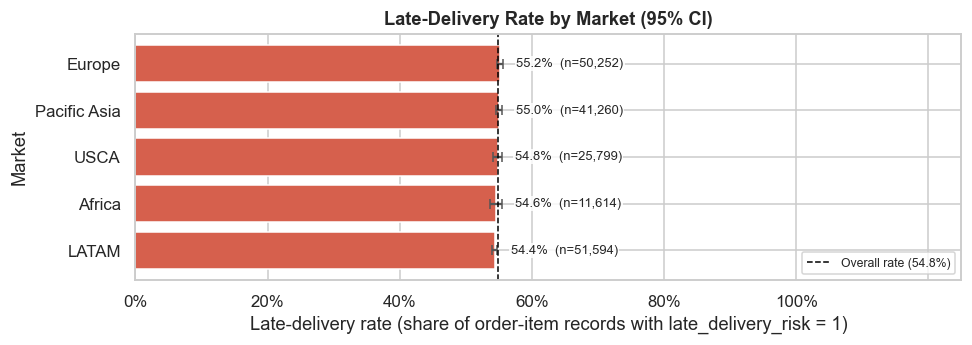

Market spread (max - min late rate): 0.9 percentage points


In [11]:
plot_rate(market_tbl, "market", "Late-Delivery Rate by Market (95% CI)",
          "late_rate_by_market.png", OVERALL_LATE)
print(f"Market spread (max - min late rate): "
      f"{100*(market_tbl.late_rate.max() - market_tbl.late_rate.min()):.1f} percentage points")

**Interpretation.** Markets differ a lot in **volume** (LATAM 51,594 records, Africa 11,614) but only slightly
in **late rate**: 54.4% (LATAM) to 55.2% (Europe), a spread of 0.9 percentage points, all within half a point
of the 54.8% baseline. At the market level, geography is only weakly associated with lateness in this dataset.

In [12]:
region_tbl = late_summary(df, "order_region", min_records=MIN_RECORDS)
style_summary(region_tbl)

order_region,record_count,share_of_records,late_count,late_rate,ci_low,ci_high,meets_min_records
Central Africa,"1,677",0.9%,972,58.0%,55.6%,60.3%,True
South Asia,"7,731",4.3%,"4,350",56.3%,55.2%,57.4%,True
East Africa,"1,852",1.0%,"1,036",55.9%,53.7%,58.2%,True
Western Europe,"27,109",15.0%,"15,140",55.8%,55.3%,56.4%,True
South of USA,"4,045",2.2%,"2,256",55.8%,54.2%,57.3%,True
Eastern Europe,"3,920",2.2%,"2,182",55.7%,54.1%,57.2%,True
East of USA,"6,915",3.8%,"3,849",55.7%,54.5%,56.8%,True
Southeast Asia,"9,539",5.3%,"5,297",55.5%,54.5%,56.5%,True
Central Asia,553,0.3%,306,55.3%,51.2%,59.4%,True
West Asia,"6,009",3.3%,"3,322",55.3%,54.0%,56.5%,True


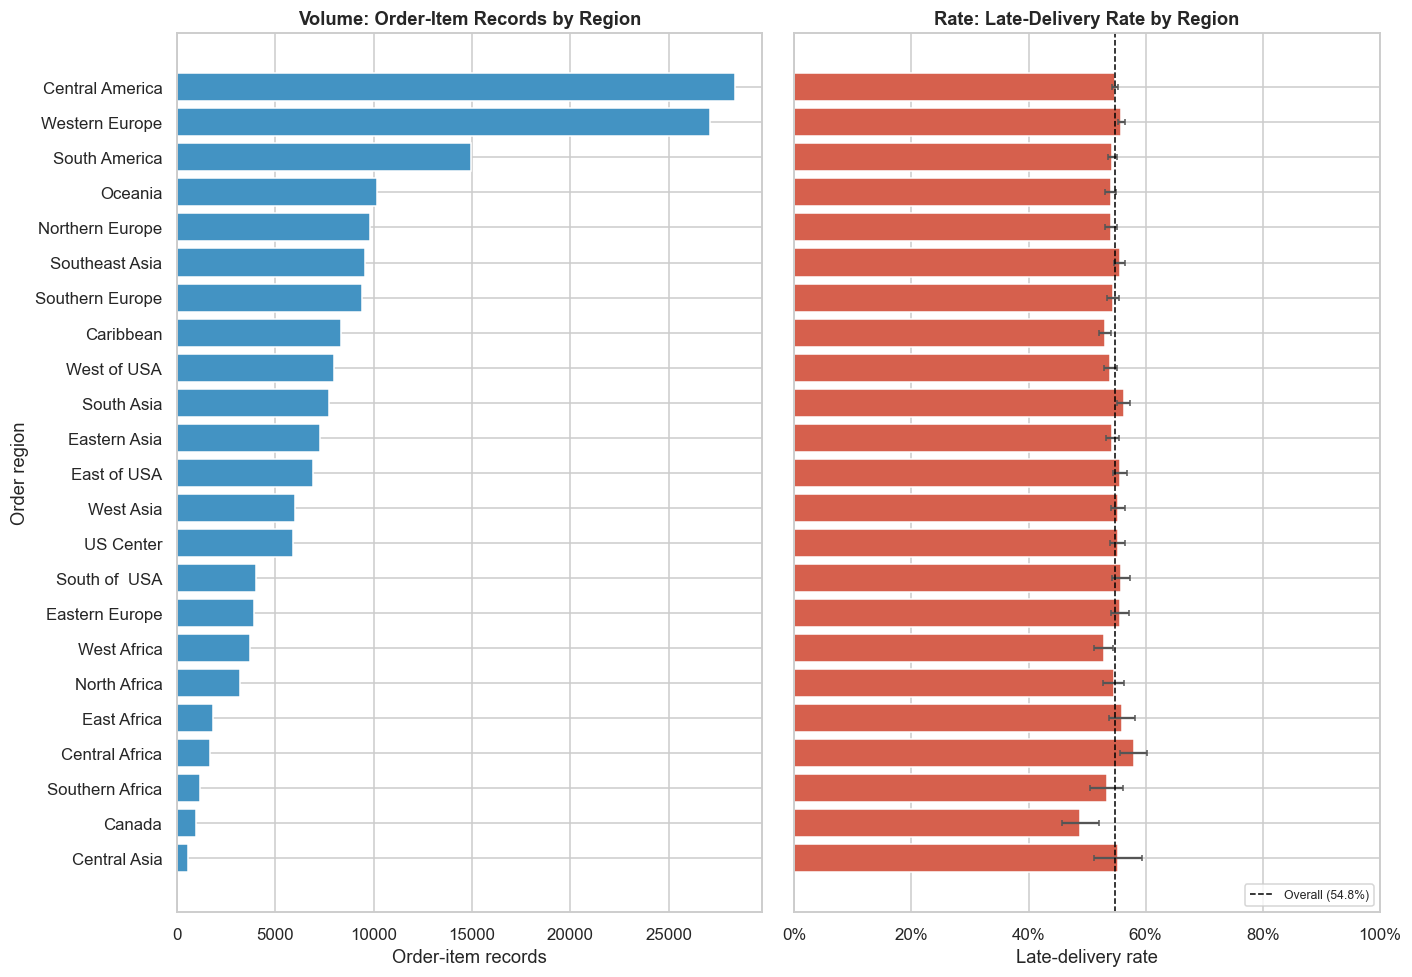

Regions below 500 records (interpret with caution): none


In [13]:
# Volume + rate for regions, sorted by volume
t = region_tbl.sort_values("record_count", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(13, max(4, 0.35 * len(t) + 1)), sharey=True)
axes[0].barh(t["order_region"], t["record_count"], color="#4393c3")
axes[0].set_title("Volume: Order-Item Records by Region"); axes[0].set_xlabel("Order-item records")
axes[0].set_ylabel("Order region")
axes[1].barh(t["order_region"], t["late_rate"], color="#d6604d",
             xerr=np.vstack([t["late_rate"] - t["ci_low"], t["ci_high"] - t["late_rate"]]),
             ecolor="#555555", capsize=2)
axes[1].axvline(OVERALL_LATE, ls="--", color="black", lw=1, label=f"Overall ({OVERALL_LATE:.1%})")
axes[1].set_title("Rate: Late-Delivery Rate by Region"); axes[1].set_xlabel("Late-delivery rate")
axes[1].set_xlim(0, 1); axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[1].legend(fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig(FIG_DIR / "late_rate_by_region.png", bbox_inches="tight"); plt.show()

small = region_tbl.loc[~region_tbl["meets_min_records"], "order_region"].tolist()
print(f"Regions below {MIN_RECORDS} records (interpret with caution): {small or 'none'}")

**Interpretation.** All 23 regions have at least 500 records, so none is excluded. Region-level late rates
mostly stay close to the baseline: 19 of 23 fall between 53% and 56%. The regions furthest from it are
**low-volume** ones — Canada (48.8%, 959 records) and Central Africa (58.0%, 1,677 records) — where the
confidence intervals are several points wide. The two largest regions, Central America and Western Europe,
are at 54.8% and 55.8%.

In [14]:
# order_country is high-cardinality: rank only countries with >= MIN_RECORDS records
country_all = late_summary(df, "order_country", min_records=MIN_RECORDS)
country_tbl = country_all[country_all["meets_min_records"]].drop(columns="meets_min_records")
print(f"Countries total: {len(country_all)} | with >= {MIN_RECORDS} records: {len(country_tbl)} "
      f"| these cover {country_tbl.record_count.sum() / len(df):.1%} of all records")
TOP_N = 15
top_countries = country_tbl.sort_values("record_count", ascending=False).head(TOP_N)
style_summary(top_countries)

Countries total: 164 | with >= 500 records: 51 | these cover 92.9% of all records


order_country,record_count,share_of_records,late_count,late_rate,ci_low,ci_high
Estados Unidos,"24,840",13.8%,"13,670",55.0%,54.4%,55.7%
Francia,"13,222",7.3%,"7,341",55.5%,54.7%,56.4%
México,"13,172",7.3%,"7,246",55.0%,54.2%,55.9%
Alemania,"9,564",5.3%,"5,383",56.3%,55.3%,57.3%
Australia,"8,497",4.7%,"4,613",54.3%,53.2%,55.3%
Brasil,"7,987",4.4%,"4,331",54.2%,53.1%,55.3%
Reino Unido,"7,302",4.0%,"3,903",53.5%,52.3%,54.6%
China,"5,758",3.2%,"3,123",54.2%,52.9%,55.5%
Italia,"4,989",2.8%,"2,672",53.6%,52.2%,54.9%
India,"4,783",2.6%,"2,684",56.1%,54.7%,57.5%


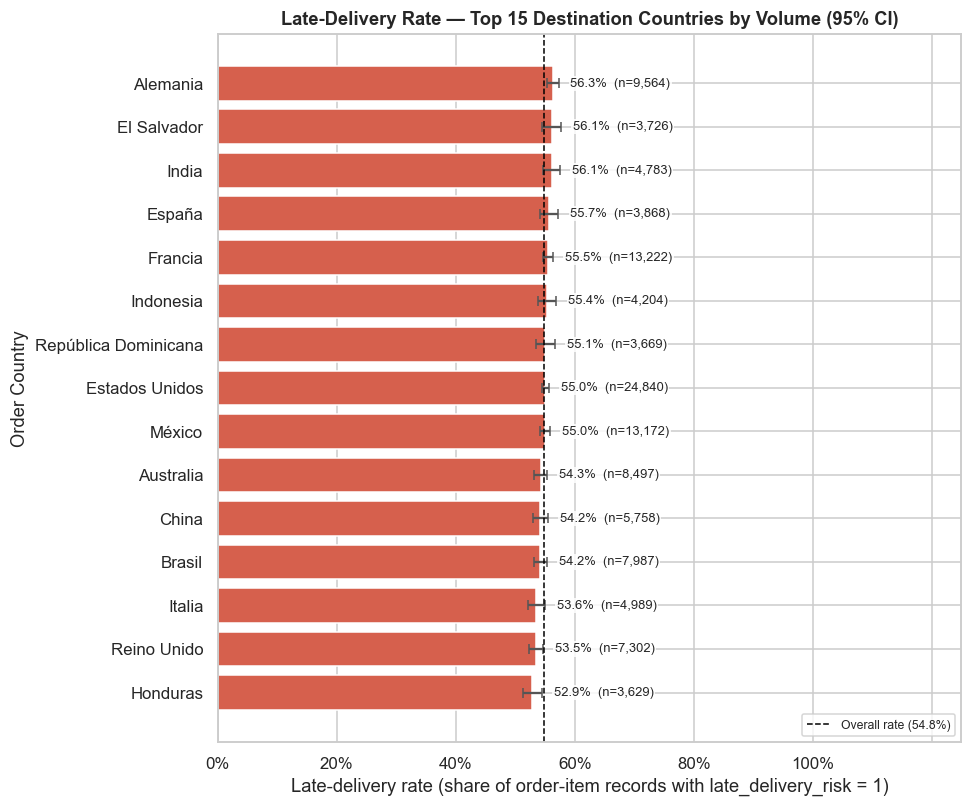

In [15]:
plot_rate(top_countries.sort_values("late_rate", ascending=False), "order_country",
          f"Late-Delivery Rate — Top {TOP_N} Destination Countries by Volume (95% CI)",
          "late_rate_by_country_top15.png", OVERALL_LATE)

**Filtering rule (documented):** `order_country` has too many values for a readable chart. Only countries
with at least `MIN_RECORDS` order-item records are ranked, and the chart shows the **top 15 by volume**.
Country names are in Spanish in the source data (e.g. *Estados Unidos*); they were not translated, to avoid
altering source values. Among high-volume countries, late rates again sit near the baseline.

## 7. Product / Category Analysis — `category_name`, `department_name`

In [16]:
cat_tbl = late_summary(df, "category_name", min_records=MIN_RECORDS)
print(f"Categories total: {len(cat_tbl)} | below {MIN_RECORDS} records: {(~cat_tbl.meets_min_records).sum()}")
style_summary(cat_tbl)

Categories total: 50 | below 500 records: 27


category_name,record_count,share_of_records,late_count,late_rate,ci_low,ci_high,meets_min_records
Golf Bags & Carts,61,0.0%,42,68.9%,56.4%,79.1%,False
Lacrosse,343,0.2%,206,60.1%,54.8%,65.1%,False
Pet Supplies,492,0.3%,290,58.9%,54.5%,63.2%,False
Cameras,592,0.3%,344,58.1%,54.1%,62.0%,True
Strength Training,111,0.1%,64,57.7%,48.4%,66.4%,False
As Seen on TV!,68,0.0%,39,57.4%,45.5%,68.4%,False
Music,434,0.2%,248,57.1%,52.4%,61.7%,False
Accessories,"1,780",1.0%,"1,014",57.0%,54.7%,59.2%,True
Fitness Accessories,309,0.2%,176,57.0%,51.4%,62.4%,False
Books,405,0.2%,229,56.5%,51.7%,61.3%,False


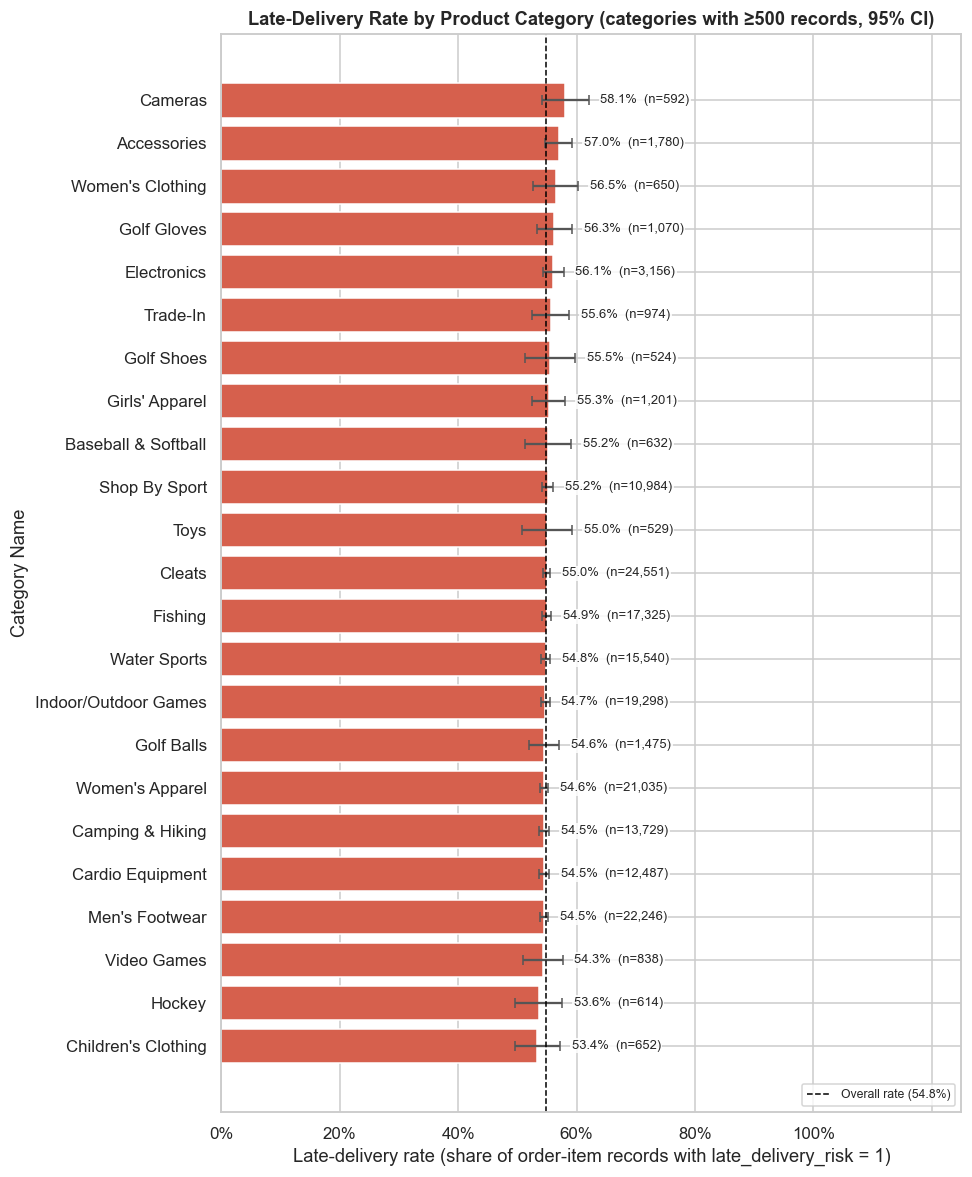

Small categories excluded from the chart (rates unreliable):


category_name,record_count,late_rate
Golf Bags & Carts,61,68.9%
Lacrosse,343,60.1%
Pet Supplies,492,58.9%
Strength Training,111,57.7%
As Seen on TV!,68,57.4%
Music,434,57.1%
Fitness Accessories,309,57.0%
Books,405,56.5%
Boxing & MMA,423,56.3%
Hunting & Shooting,440,56.1%


In [17]:
reliable_cats = cat_tbl[cat_tbl["meets_min_records"]]
plot_rate(reliable_cats, "category_name",
          f"Late-Delivery Rate by Product Category (categories with ≥{MIN_RECORDS} records, 95% CI)",
          "late_rate_by_category.png", OVERALL_LATE)

small_cats = cat_tbl.loc[~cat_tbl["meets_min_records"], ["category_name", "record_count", "late_rate"]]
print("Small categories excluded from the chart (rates unreliable):")
display(small_cats.style.format({"record_count": "{:,.0f}", "late_rate": "{:.1%}"}).hide(axis="index"))

In [18]:
dept_tbl = late_summary(df, "department_name", min_records=MIN_RECORDS)
style_summary(dept_tbl)

department_name,record_count,share_of_records,late_count,late_rate,ci_low,ci_high,meets_min_records
Pet Shop,492,0.3%,290,58.9%,54.5%,63.2%,False
Book Shop,405,0.2%,229,56.5%,51.7%,61.3%,False
Health and Beauty,362,0.2%,202,55.8%,50.7%,60.8%,False
Fitness,"2,479",1.4%,"1,377",55.5%,53.6%,57.5%,True
Outdoors,"9,686",5.4%,"5,375",55.5%,54.5%,56.5%,True
Technology,"1,465",0.8%,806,55.0%,52.5%,57.5%,True
Golf,"33,220",18.4%,"18,198",54.8%,54.2%,55.3%,True
Fan Shop,"66,861",37.0%,"36,623",54.8%,54.4%,55.2%,True
Apparel,"48,998",27.1%,"26,825",54.7%,54.3%,55.2%,True
Footwear,"14,525",8.0%,"7,949",54.7%,53.9%,55.5%,True


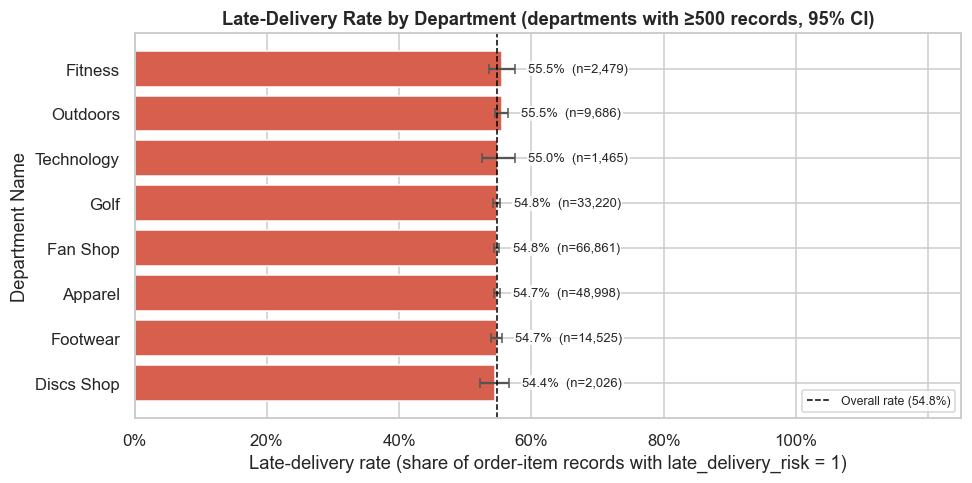

Departments below 500 records (excluded from the chart): ['Pet Shop', 'Book Shop', 'Health and Beauty']


In [19]:
reliable_depts = dept_tbl[dept_tbl["meets_min_records"]]
plot_rate(reliable_depts, "department_name",
          f"Late-Delivery Rate by Department (departments with ≥{MIN_RECORDS} records, 95% CI)",
          "late_rate_by_department.png", OVERALL_LATE)
small_depts = dept_tbl.loc[~dept_tbl["meets_min_records"], "department_name"].tolist()
print(f"Departments below {MIN_RECORDS} records (excluded from the chart): {small_depts or 'none'}")

**Interpretation.**

- For the 23 categories with at least 500 records, late rates run from 53.4% to 58.1%. Both ends are
  categories with fewer than 700 records; every category above 10,000 records is between 54.5% and 55.2%.
  Product type is only weakly associated with lateness at this level.
- The most extreme rates (47.7% to 68.9%) appear in the 27 **small categories**, some with as few as 61
  records. Their wide confidence intervals make these rates unreliable, which is why they are excluded from
  the ranked chart using the `MIN_RECORDS` threshold. Together they hold 4.8% of records.
- Volume is very concentrated: nine categories (Cleats, Men's Footwear, Women's Apparel, Indoor/Outdoor
  Games, Fishing, Water Sports, Camping & Hiking, Cardio Equipment, Shop By Sport) account for 87% of records.
- Departments with at least 500 records range from 54.4% to 55.5%. Pet Shop, Book Shop, and Health and
  Beauty are below the threshold and are left out of the department chart.

## 8. Customer Segment & Payment Type — `customer_segment`, `type`

In [20]:
seg_tbl = late_summary(df, "customer_segment")
display(style_summary(seg_tbl))
type_tbl = late_summary(df, "type")
display(style_summary(type_tbl))

customer_segment,record_count,share_of_records,late_count,late_rate,ci_low,ci_high
Home Office,"32,226",17.9%,"17,747",55.1%,54.5%,55.6%
Consumer,"93,504",51.8%,"51,248",54.8%,54.5%,55.1%
Corporate,"54,789",30.4%,"29,982",54.7%,54.3%,55.1%


type,record_count,share_of_records,late_count,late_rate,ci_low,ci_high
PAYMENT,"41,725",23.1%,"24,004",57.5%,57.1%,58.0%
DEBIT,"69,295",38.4%,"39,649",57.2%,56.8%,57.6%
CASH,"19,616",10.9%,"11,109",56.6%,55.9%,57.3%
TRANSFER,"49,883",27.6%,"24,215",48.5%,48.1%,49.0%


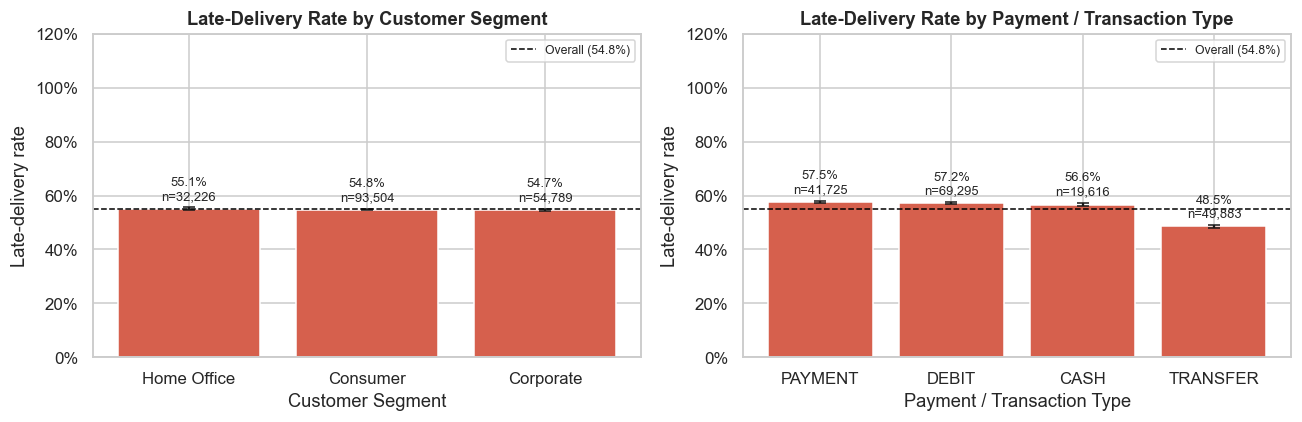

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (t, col, title) in zip(axes, [(seg_tbl, "customer_segment", "Customer Segment"),
                                      (type_tbl, "type", "Payment / Transaction Type")]):
    t = t.sort_values("late_rate", ascending=False)
    ax.bar(t[col], t["late_rate"], color="#d6604d",
           yerr=np.vstack([t["late_rate"] - t["ci_low"], t["ci_high"] - t["late_rate"]]), capsize=4)
    ax.axhline(OVERALL_LATE, ls="--", color="black", lw=1, label=f"Overall ({OVERALL_LATE:.1%})")
    for i, (r, hi, n) in enumerate(zip(t["late_rate"], t["ci_high"], t["record_count"])):
        ax.text(i, hi + 0.03, f"{r:.1%}\nn={n:,}", ha="center", fontsize=8.5)
    ax.set_ylim(0, 1.2); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_title(f"Late-Delivery Rate by {title}"); ax.set_xlabel(title); ax.set_ylabel("Late-delivery rate")
    ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "late_rate_by_segment_and_type.png", bbox_inches="tight"); plt.show()

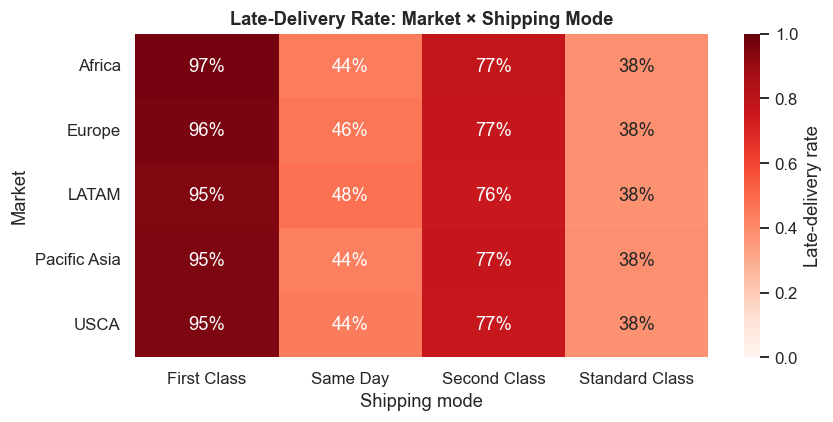

In [22]:
# Market x shipping mode: does the shipping-mode pattern hold in every market?
pivot = df.pivot_table(index="market", columns="shipping_mode", values=TARGET, aggfunc="mean")
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt=".0%", cmap="Reds", vmin=0, vmax=1, cbar_kws={"label": "Late-delivery rate"}, ax=ax)
ax.set_title("Late-Delivery Rate: Market × Shipping Mode"); ax.set_xlabel("Shipping mode"); ax.set_ylabel("Market")
fig.tight_layout(); fig.savefig(FIG_DIR / "late_rate_market_x_shipping_mode.png", bbox_inches="tight"); plt.show()

**Interpretation.**

- **Customer segment.** Consumer, Corporate, and Home Office are within 0.4 percentage points of each other
  (54.7% to 55.1%).
- **Payment type.** PAYMENT (57.5%), DEBIT (57.2%), and CASH (56.6%) are close together, but TRANSFER is
  clearly lower at 48.5%. Section 10 shows this gap comes from order status: all canceled and
  suspected-fraud records are TRANSFER records and none of them is flagged late. With those records
  excluded, TRANSFER is at 57.5%, in line with the other types.
- **Market × shipping mode.** The shipping-mode pattern repeats inside every market: the columns (modes)
  differ far more than the rows (markets). Shipping mode, not geography, shows the larger categorical
  differences — something to examine properly in modeling.

## 9. Delivery Status — `delivery_status` (⚠️ LEAKAGE — EDA ONLY)

> `delivery_status` reveals or nearly reveals the target and is **forbidden for predictive modeling**.

It is analysed here **only** to demonstrate why.

In [23]:
ds_ct = pd.crosstab(df["delivery_status"], df[TARGET], margins=True, margins_name="Total")
ds_ct.columns = [f"late_delivery_risk={c}" if c != "Total" else c for c in ds_ct.columns]
display(ds_ct)
ds_tbl = late_summary(df, "delivery_status")
style_summary(ds_tbl)

,late_delivery_risk=0,late_delivery_risk=1,Total
delivery_status,,,
Advance shipping,41592,0,41592
Late delivery,0,98977,98977
Shipping canceled,7754,0,7754
Shipping on time,32196,0,32196
Total,81542,98977,180519


delivery_status,record_count,share_of_records,late_count,late_rate,ci_low,ci_high
Late delivery,"98,977",54.8%,"98,977",100.0%,100.0%,100.0%
Advance shipping,"41,592",23.0%,0,0.0%,0.0%,0.0%
Shipping canceled,"7,754",4.3%,0,0.0%,0.0%,0.0%
Shipping on time,"32,196",17.8%,0,0.0%,0.0%,0.0%


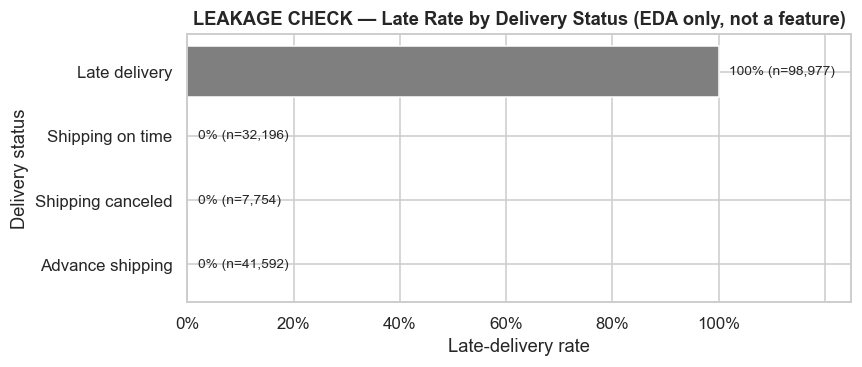

In [24]:
t = ds_tbl.sort_values("late_rate")
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(t["delivery_status"], t["late_rate"], color="#7f7f7f")
for i, (r, n) in enumerate(zip(t["late_rate"], t["record_count"])):
    ax.text(r + 0.02, i, f"{r:.0%} (n={n:,})", va="center", fontsize=9)
ax.set_xlim(0, 1.25); ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}" if x <= 1 else ""))
ax.set_title("LEAKAGE CHECK — Late Rate by Delivery Status (EDA only, not a feature)")
ax.set_xlabel("Late-delivery rate"); ax.set_ylabel("Delivery status")
fig.tight_layout(); fig.savefig(FIG_DIR / "leakage_check_delivery_status.png", bbox_inches="tight"); plt.show()

**Interpretation.** Each delivery status maps to exactly one target value — "Late delivery" is always
`late_delivery_risk = 1` (98,977 records), and "Advance shipping", "Shipping on time", and "Shipping canceled"
are always `0`. In other words, `delivery_status` *is* the answer written as text. Any model given this column
would look perfect and be useless in practice, because the status is only known **after** the delivery outcome.
This confirms its **EDA-ONLY / forbidden** classification in `docs/FEATURE_POLICY.md`.

## 10. Order Status — `order_status` (⚠️ REVIEW REQUIRED)

`docs/FEATURE_POLICY.md` marks `order_status` as **REVIEW REQUIRED**. That warning is preserved here: it is
analysed descriptively, but it is **not** declared prediction-safe.

In [25]:
os_tbl = late_summary(df, "order_status", min_records=MIN_RECORDS)
style_summary(os_tbl)

order_status,record_count,share_of_records,late_count,late_rate,ci_low,ci_high,meets_min_records
PENDING,"20,227",11.2%,"11,712",57.9%,57.2%,58.6%,True
PENDING_PAYMENT,"39,832",22.1%,"22,922",57.5%,57.1%,58.0%,True
COMPLETE,"59,491",33.0%,"34,199",57.5%,57.1%,57.9%,True
PAYMENT_REVIEW,"1,893",1.0%,"1,082",57.2%,54.9%,59.4%,True
PROCESSING,"21,902",12.1%,"12,503",57.1%,56.4%,57.7%,True
CLOSED,"19,616",10.9%,"11,109",56.6%,55.9%,57.3%,True
ON_HOLD,"9,804",5.4%,"5,450",55.6%,54.6%,56.6%,True
CANCELED,"3,692",2.0%,0,0.0%,0.0%,0.1%,True
SUSPECTED_FRAUD,"4,062",2.3%,0,0.0%,0.0%,0.1%,True


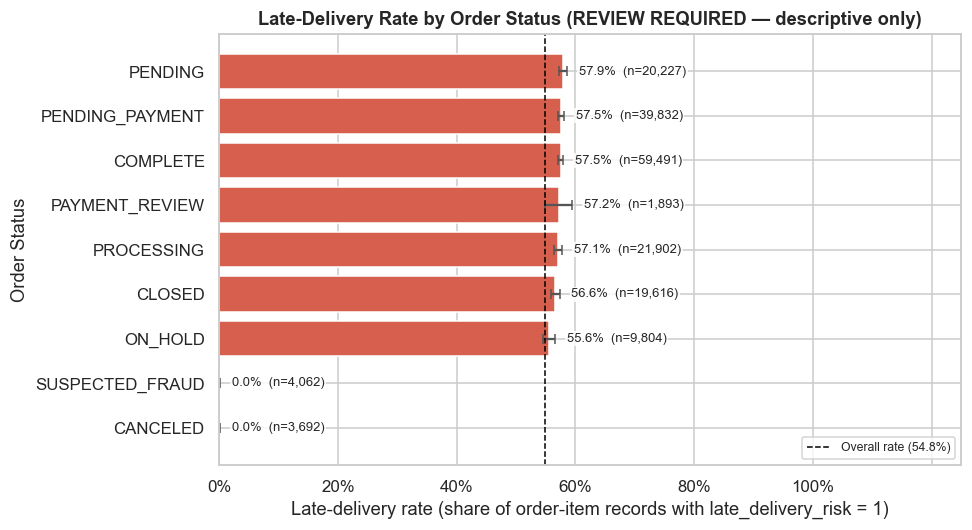

delivery_status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
order_status,,,,
CANCELED,0,0,3692,0
CLOSED,4809,11109,0,3698
COMPLETE,14136,34199,0,11156
ON_HOLD,2413,5450,0,1941
PAYMENT_REVIEW,420,1082,0,391
PENDING,4857,11712,0,3658
PENDING_PAYMENT,9588,22922,0,7322
PROCESSING,5369,12503,0,4030
SUSPECTED_FRAUD,0,0,4062,0


In [26]:
plot_rate(os_tbl, "order_status", "Late-Delivery Rate by Order Status (REVIEW REQUIRED — descriptive only)",
          "late_rate_by_order_status.png", OVERALL_LATE)
pd.crosstab(df["order_status"], df["delivery_status"])

In [27]:
# Each order status maps to one payment type; this explains the TRANSFER gap seen in Section 8
display(pd.crosstab(df["order_status"], df["type"]))

never_late = os_tbl.loc[os_tbl["late_count"] == 0, "order_status"].tolist()
not_shipped = df["order_status"].isin(never_late)
print(f"Order statuses with zero late records: {never_late} ({int(not_shipped.sum()):,} records)")
print(f"Late rate excluding those records: {df.loc[~not_shipped, TARGET].mean():.2%}")
print("Payment-type late rate excluding those records:")
print(df[~not_shipped].groupby("type")[TARGET].mean().map("{:.2%}".format).to_string())

type,CASH,DEBIT,PAYMENT,TRANSFER
order_status,,,,
CANCELED,0,0,0,3692
CLOSED,19616,0,0,0
COMPLETE,0,59491,0,0
ON_HOLD,0,9804,0,0
PAYMENT_REVIEW,0,0,1893,0
PENDING,0,0,0,20227
PENDING_PAYMENT,0,0,39832,0
PROCESSING,0,0,0,21902
SUSPECTED_FRAUD,0,0,0,4062


Order statuses with zero late records: ['CANCELED', 'SUSPECTED_FRAUD'] (7,754 records)
Late rate excluding those records: 57.29%
Payment-type late rate excluding those records:
type
CASH        56.63%
DEBIT       57.22%
PAYMENT     57.53%
TRANSFER    57.48%


**Interpretation.** CANCELED (3,692 records) and SUSPECTED_FRAUD (4,062 records) have zero late records and
are exactly the 7,754 "Shipping canceled" records, which makes `order_status` look predictive. The other seven
statuses sit between 55.6% and 57.9%. Each order status also maps to a single payment type, so `type` inherits
the same pattern: TRANSFER is the only type containing canceled and suspected-fraud records.

Whether `order_status` can be used depends on **when the prediction is made**: a status recorded at order time
might be usable, but a status updated after fulfilment would leak future information. Until the team defines
the prediction timestamp, it stays **REVIEW REQUIRED**. Because `type` is tied to `order_status`, it needs the
same timing review.

## 11. High-Cardinality Review

In [28]:
high_card = cat_overview[cat_overview["unique_values"] > 60][["column", "unique_values", "feature_policy"]].copy()
high_card["records_in_top_10_values"] = [
    df[c].value_counts(normalize=True).head(10).sum() for c in high_card["column"]
]
high_card["values_with_lt_50_records"] = [
    int((df[c].value_counts() < 50).sum()) for c in high_card["column"]
]
high_card.style.format({"records_in_top_10_values": "{:.1%}"}).hide(axis="index")

column,unique_values,feature_policy,records_in_top_10_values,values_with_lt_50_records
product_name,118,REVIEW REQUIRED,87.1%,13
product_image,118,REVIEW REQUIRED,87.1%,13
order_country,164,REVIEW REQUIRED,55.5%,52
customer_city,563,REVIEW REQUIRED,47.9%,27
order_state,1089,REVIEW REQUIRED,19.4%,585
order_city,3597,REVIEW REQUIRED,9.1%,2777


**Interpretation.**

- `product_name`, `order_city`, `order_state`, `customer_city`, `order_country` and `product_image` have
  too many distinct values for a readable chart, and many values have very few records — per-value late
  rates would be dominated by noise.
- `product_image` is just a URL; `product_name` largely duplicates `category_name` at a finer, noisier level.
- Useful handling: aggregate up (country → region → market, product → category → department) or use
  top-N with a minimum-count threshold, as done above. Any encoding decision belongs to the modeling phase.

## 12. Required Summary Tables (consolidated)

The four required tables, with clear order-item-level labels.

In [29]:
def required_table(t, col):
    out = t[[col, "record_count", "late_count", "late_rate"]].rename(
        columns={"record_count": "order_item_records", "late_count": "late_order_item_records"})
    return out.style.format({"order_item_records": "{:,.0f}", "late_order_item_records": "{:,.0f}",
                             "late_rate": "{:.1%}"}).hide(axis="index").set_caption(
        f"Late Delivery by {col.replace('_', ' ').title()}")

display(required_table(ship_tbl, "shipping_mode"))
display(required_table(region_tbl, "order_region"))
display(required_table(cat_tbl, "category_name"))
display(required_table(market_tbl, "market"))

shipping_mode,order_item_records,late_order_item_records,late_rate
First Class,"27,814","26,513",95.3%
Second Class,"35,216","26,987",76.6%
Same Day,"9,737","4,454",45.7%
Standard Class,"107,752","41,023",38.1%


order_region,order_item_records,late_order_item_records,late_rate
Central Africa,"1,677",972,58.0%
South Asia,"7,731","4,350",56.3%
East Africa,"1,852","1,036",55.9%
Western Europe,"27,109","15,140",55.8%
South of USA,"4,045","2,256",55.8%
Eastern Europe,"3,920","2,182",55.7%
East of USA,"6,915","3,849",55.7%
Southeast Asia,"9,539","5,297",55.5%
Central Asia,553,306,55.3%
West Asia,"6,009","3,322",55.3%


category_name,order_item_records,late_order_item_records,late_rate
Golf Bags & Carts,61,42,68.9%
Lacrosse,343,206,60.1%
Pet Supplies,492,290,58.9%
Cameras,592,344,58.1%
Strength Training,111,64,57.7%
As Seen on TV!,68,39,57.4%
Music,434,248,57.1%
Accessories,"1,780","1,014",57.0%
Fitness Accessories,309,176,57.0%
Books,405,229,56.5%


market,order_item_records,late_order_item_records,late_rate
Europe,"50,252","27,743",55.2%
Pacific Asia,"41,260","22,712",55.0%
USCA,"25,799","14,138",54.8%
Africa,"11,614","6,340",54.6%
LATAM,"51,594","28,044",54.4%


## 13. Unique-Order Sensitivity Check

Because one order can have several items, an order with many items counts several times at row level.
To check whether this distorts the shipping-mode result, the analysis is repeated at **unique-order level**.

**Aggregation rule:** this is only defensible if `shipping_mode` and `late_delivery_risk` are constant
within each order. The cell checks that first; if they are not constant, it stops instead of inventing a rule.

In [30]:
per_order = df.groupby("order_id").agg(n_modes=("shipping_mode", "nunique"),
                                       n_targets=(TARGET, "nunique"))
consistent = (per_order["n_modes"] == 1).all() and (per_order["n_targets"] == 1).all()
print(f"shipping_mode constant within every order: {(per_order['n_modes'] == 1).all()}")
print(f"late_delivery_risk constant within every order: {(per_order['n_targets'] == 1).all()}")

if consistent:
    orders = df.groupby("order_id").agg(shipping_mode=("shipping_mode", "first"), late=(TARGET, "first"))
    order_lvl = (orders.groupby("shipping_mode")["late"]
                 .agg(unique_orders="size", late_unique_orders="sum").reset_index())
    order_lvl["order_level_late_rate"] = order_lvl["late_unique_orders"] / order_lvl["unique_orders"]
    compare = ship_tbl[["shipping_mode", "record_count", "late_rate"]].rename(
        columns={"record_count": "order_item_records", "late_rate": "item_level_late_rate"}
    ).merge(order_lvl, on="shipping_mode")
    compare["difference_pp"] = 100 * (compare["item_level_late_rate"] - compare["order_level_late_rate"])
    display(compare.style.format({"order_item_records": "{:,.0f}", "unique_orders": "{:,.0f}",
                                  "late_unique_orders": "{:,.0f}", "item_level_late_rate": "{:.1%}",
                                  "order_level_late_rate": "{:.1%}", "difference_pp": "{:+.2f}"}).hide(axis="index"))
else:
    print("FLAG: values vary within some orders — no defensible order-level rule; skipping (flag for team).")

shipping_mode constant within every order: True
late_delivery_risk constant within every order: True


shipping_mode,order_item_records,item_level_late_rate,unique_orders,late_unique_orders,order_level_late_rate,difference_pp
First Class,"27,814",95.3%,"10,079","9,602",95.3%,+0.06
Second Class,"35,216",76.6%,"12,778","9,803",76.7%,-0.09
Same Day,"9,737",45.7%,"3,571","1,648",46.1%,-0.41
Standard Class,"107,752",38.1%,"39,324","14,995",38.1%,-0.06


**Interpretation.** Shipping mode and the target are fixed per order, so taking each order's single value is
a defensible aggregation (no rows are arbitrarily discarded). The item-level and order-level late rates differ
by at most 0.41 percentage points (Same Day), so the shipping-mode conclusion is **not** an artifact of
multi-item orders.

## 14. Interactive Visualizations (Plotly)

Interactive versions of four key views. Each chart is also saved as a standalone HTML file in `reports/figures/categorical/interactive_*.html`. The files load plotly.js from the CDN, so they are small and need an internet connection. GitHub does not render Plotly output inside notebooks; open the HTML files to hover and use the dropdown.

In [31]:
def show_and_save(fig, name):
    fname = f"interactive_{name}.html"
    # A fixed div_id keeps the saved file identical across reruns.
    fig.write_html(FIG_DIR / fname, include_plotlyjs="cdn", div_id=name)
    print(f"Saved {(FIG_DIR / fname).relative_to(REPO_ROOT).as_posix()}")
    fig.show()

OVERALL_LABEL = f"Overall late rate ({OVERALL_LATE:.1%})"
HOVER_COLS = ["record_count", "late_count", "late_rate", "ci_low", "ci_high"]
HOVER_DETAILS = (
    "Late rate: %{customdata[2]:.1%}<br>"
    "Order-item records: %{customdata[0]:,}<br>"
    "Late records: %{customdata[1]:,}<br>"
    "95% CI: %{customdata[3]:.1%} to %{customdata[4]:.1%}<extra></extra>"
)

In [32]:
# 1) Late rate by shipping mode
t = ship_tbl
fig = go.Figure(go.Bar(
    x=t["shipping_mode"], y=t["late_rate"],
    error_y=dict(type="data", symmetric=False,
                 array=t["ci_high"] - t["late_rate"], arrayminus=t["late_rate"] - t["ci_low"]),
    customdata=t[HOVER_COLS].to_numpy(),
    hovertemplate="<b>%{x}</b><br>" + HOVER_DETAILS,
    marker_color="#d6604d",
))
fig.add_hline(y=OVERALL_LATE, line_dash="dash", annotation_text=OVERALL_LABEL)
fig.update_layout(title="Late-Delivery Rate by Shipping Mode (order-item records)",
                  xaxis_title="Shipping mode", yaxis_title="Late-delivery rate",
                  yaxis=dict(tickformat=".0%", range=[0, 1.05]))
show_and_save(fig, "shipping_mode_late_rate")

Saved reports/figures/categorical/interactive_shipping_mode_late_rate.html


In [33]:
# 2) Market x shipping mode heatmap
pivot_counts = df.pivot_table(index="market", columns="shipping_mode", values=TARGET, aggfunc="size")
fig = go.Figure(go.Heatmap(
    z=pivot.to_numpy(), x=pivot.columns.tolist(), y=pivot.index.tolist(),
    customdata=pivot_counts.to_numpy(),
    text=pivot.map("{:.1%}".format).to_numpy(), texttemplate="%{text}",
    colorscale="Reds", zmin=0, zmax=1,
    colorbar=dict(title="Late-delivery rate", tickformat=".0%"),
    hovertemplate=("<b>%{y} / %{x}</b><br>Late rate: %{z:.1%}<br>"
                   "Order-item records: %{customdata:,}<extra></extra>"),
))
fig.update_layout(title="Late-Delivery Rate: Market × Shipping Mode (order-item records)",
                  xaxis_title="Shipping mode", yaxis_title="Market")
show_and_save(fig, "market_shipping_mode_heatmap")
print(f"Smallest cell: {int(pivot_counts.min().min()):,} records")
print("Late-rate spread across markets within each shipping mode (percentage points):")
print(((pivot.max() - pivot.min()) * 100).round(2).to_string())

Saved reports/figures/categorical/interactive_market_shipping_mode_heatmap.html


Smallest cell: 668 records
Late-rate spread across markets within each shipping mode (percentage points):
shipping_mode
First Class      2.250
Same Day         4.510
Second Class     1.840
Standard Class   0.620


In [34]:
# 3) Order region: volume vs late rate
t = region_tbl[region_tbl["meets_min_records"]]
fig = go.Figure(go.Scatter(
    x=t["record_count"], y=t["late_rate"], mode="markers",
    marker=dict(size=t["record_count"], sizemode="area",
                sizeref=2.0 * t["record_count"].max() / 45**2, sizemin=4,
                color="#4393c3", opacity=0.7),
    text=t["order_region"],
    customdata=t[HOVER_COLS].to_numpy(),
    hovertemplate="<b>%{text}</b><br>" + HOVER_DETAILS,
))
fig.add_hline(y=OVERALL_LATE, line_dash="dash", annotation_text=OVERALL_LABEL)
fig.update_layout(title=f"Order Region: Volume vs Late-Delivery Rate (regions with ≥{MIN_RECORDS} records)",
                  xaxis_title="Order-item records (volume)", yaxis_title="Late-delivery rate",
                  xaxis=dict(tickformat=","), yaxis=dict(tickformat=".1%"))
show_and_save(fig, "order_region_volume_vs_late_rate")

Saved reports/figures/categorical/interactive_order_region_volume_vs_late_rate.html


In [35]:
# 4) Category late rate with a dropdown to change the sort order
t = reliable_cats
order_by_rate = t.sort_values("late_rate")["category_name"].tolist()
order_by_volume = t.sort_values("record_count")["category_name"].tolist()
fig = go.Figure(go.Bar(
    x=t["late_rate"], y=t["category_name"], orientation="h",
    error_x=dict(type="data", symmetric=False,
                 array=t["ci_high"] - t["late_rate"], arrayminus=t["late_rate"] - t["ci_low"]),
    customdata=t[HOVER_COLS].to_numpy(),
    hovertemplate="<b>%{y}</b><br>" + HOVER_DETAILS,
    marker_color="#d6604d",
))
fig.add_vline(x=OVERALL_LATE, line_dash="dash", annotation_text=OVERALL_LABEL)
fig.update_layout(
    title=f"Late-Delivery Rate by Product Category (categories with ≥{MIN_RECORDS} records)",
    xaxis_title="Late-delivery rate", yaxis_title="Category",
    xaxis=dict(tickformat=".0%"),
    yaxis=dict(categoryorder="array", categoryarray=order_by_rate),
    height=max(500, 22 * len(t)), margin=dict(l=180),
    updatemenus=[dict(
        type="dropdown", x=1.0, xanchor="right", y=1.08, yanchor="bottom",
        buttons=[
            dict(label="Sort by late rate", method="relayout",
                 args=[{"yaxis.categoryarray": order_by_rate}]),
            dict(label="Sort by record count", method="relayout",
                 args=[{"yaxis.categoryarray": order_by_volume}]),
        ],
    )],
)
show_and_save(fig, "category_name_late_rate")

Saved reports/figures/categorical/interactive_category_name_late_rate.html


## 15. Figures Saved

In [36]:
for p in sorted(FIG_DIR.glob("*.png")) + sorted(FIG_DIR.glob("*.html")):
    print(p.relative_to(REPO_ROOT).as_posix())

reports/figures/categorical/late_rate_by_category.png
reports/figures/categorical/late_rate_by_country_top15.png
reports/figures/categorical/late_rate_by_department.png
reports/figures/categorical/late_rate_by_market.png
reports/figures/categorical/late_rate_by_order_status.png
reports/figures/categorical/late_rate_by_region.png
reports/figures/categorical/late_rate_by_segment_and_type.png
reports/figures/categorical/late_rate_by_shipping_mode.png
reports/figures/categorical/late_rate_market_x_shipping_mode.png
reports/figures/categorical/leakage_check_delivery_status.png
reports/figures/categorical/target_distribution.png
reports/figures/categorical/interactive_category_name_late_rate.html
reports/figures/categorical/interactive_market_shipping_mode_heatmap.html
reports/figures/categorical/interactive_order_region_volume_vs_late_rate.html
reports/figures/categorical/interactive_shipping_mode_late_rate.html


## 16. Final Findings

**Most important categorical patterns**
- **Shipping mode shows by far the largest categorical differences.** First Class (95.3%) and Second Class
  (76.6%) have much higher late rates than Same Day (45.7%) and Standard Class (38.1%), against a 54.8%
  baseline. The pattern holds inside every market and at unique-order level. Each mode maps to one scheduled
  shipping duration, but the late rate is not simply ordered by that duration.
- **Market, region, customer segment and product category** show only small differences from the overall
  baseline once small categories are set aside.
- **Payment type** shows one gap (TRANSFER at 48.5% versus about 57% for the others) that is fully accounted
  for by canceled and suspected-fraud orders, which are all TRANSFER and never late.

**Variables deserving later investigation**
- `shipping_mode` together with `days_for_shipment_scheduled` (prediction-safe candidates, but one-to-one
  with each other).
- Region / market interactions with shipping mode, and order-date patterns.

**Categories requiring caution (small sample size)**
- 27 of 50 product categories and 3 of 11 departments are below the `MIN_RECORDS` threshold — their extreme
  rates have wide confidence intervals and were excluded from rankings. All 23 regions meet the threshold,
  but the regions furthest from the baseline (Canada, Central Africa) are low-volume.

**Leakage / post-outcome variables identified**
- `delivery_status` — exact restatement of the target → **forbidden** (EDA only).
- `order_status` — **REVIEW REQUIRED**; depends on the prediction timestamp. `type` is tied one-to-one to
  order-status groups and needs the same review.
- (From policy) `days_for_shipping_real`, `shipping_date_dateorders` — post-outcome, EDA only.

**Limitations from order-item grain**
- Row counts are order-item records, not orders. Multi-item orders are weighted more heavily at row level;
  the sensitivity check shows this does not change the shipping-mode conclusion, but future modeling must
  still split by `order_id`.
- Confidence intervals treat rows as independent. Items in one order share an outcome, so the true
  uncertainty is somewhat wider than shown.
- All findings are descriptive associations within this dataset. No models were trained.